In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Dataset source
- https://ourworldindata.org/grapher/gdp-per-capita-maddison-project-database
- https://ourworldindata.org/grapher/military-spending-as-a-share-of-gdp-sipri?mapSelect=~IND

In [3]:
df1=pd.read_csv('gdp-per-capita-maddison-project-database.csv')
df2=pd.read_csv('military-spending-as-a-share-of-gdp-sipri.csv')

In [4]:
df1

,Entity,Code,Year,GDP per capita,900793-annotations
0,Afghanistan,AFG,1950,1156.0000,NaN
1,Afghanistan,AFG,1951,1170.0000,NaN
2,Afghanistan,AFG,1952,1189.0000,NaN
3,Afghanistan,AFG,1953,1240.0000,NaN
4,Afghanistan,AFG,1954,1245.0000,NaN
...,...,...,...,...,...
21581,Zimbabwe,ZWE,2018,1900.1992,NaN
21582,Zimbabwe,ZWE,2019,1753.0244,NaN
21583,Zimbabwe,ZWE,2020,1585.9728,NaN
21584,Zimbabwe,ZWE,2021,1687.2532,NaN


In [5]:
df2

,Entity,Code,Year,Military expenditure (% of GDP),World regions according to OWID
0,Afghanistan,AFG,1970,1.629606,NaN
1,Afghanistan,AFG,1973,1.868910,NaN
2,Afghanistan,AFG,1974,1.610825,NaN
3,Afghanistan,AFG,1975,1.722066,NaN
4,Afghanistan,AFG,1976,2.046087,NaN
...,...,...,...,...,...
8361,Zimbabwe,ZWE,2020,0.974989,NaN
8362,Zimbabwe,ZWE,2021,1.567779,NaN
8363,Zimbabwe,ZWE,2022,0.994988,NaN
8364,Zimbabwe,ZWE,2023,0.209794,Africa


#### Part 1 Answers for report
1. I want to study the relationship between GDP per capita in India and the total fraction of it being allocated for military development of Indian Defense Sector.
2. Since some kind of Investment has already been done in the previous year so there should be a decay in investing because physical infrastructure does not get destroyed within a year.
3. Initially, it increased suddenly then it is decaying gradually.

In [6]:
subset1=df1[df1['Code']=='IND']  ## From GDP Dataset I am taking data of India 
subset1

,Entity,Code,Year,GDP per capita,900793-annotations
7815,India,IND,1600,1264.0000,NaN
7816,India,IND,1650,1189.0000,NaN
7817,India,IND,1700,1162.0000,NaN
7818,India,IND,1750,1068.0000,NaN
7819,India,IND,1801,1033.0000,NaN
...,...,...,...,...,...
7962,India,IND,2018,7046.4365,NaN
7963,India,IND,2019,7293.9897,NaN
7964,India,IND,2020,6730.5470,NaN
7965,India,IND,2021,7315.1216,NaN


In [7]:
subset1=subset1[subset1['Year']>=1956] 
subset1

,Entity,Code,Year,GDP per capita,900793-annotations
7900,India,IND,1956,1117.0000,NaN
7901,India,IND,1957,1084.0000,NaN
7902,India,IND,1958,1141.0000,NaN
7903,India,IND,1959,1143.0000,NaN
7904,India,IND,1960,1200.0000,NaN
...,...,...,...,...,...
7962,India,IND,2018,7046.4365,NaN
7963,India,IND,2019,7293.9897,NaN
7964,India,IND,2020,6730.5470,NaN
7965,India,IND,2021,7315.1216,NaN


In [8]:
subset1=subset1[['Year','GDP per capita']]  ## Cleaned subset of GDP data for India and Year>=1956
subset1.head()

,Year,GDP per capita
7900,1956,1117.0
7901,1957,1084.0
7902,1958,1141.0
7903,1959,1143.0
7904,1960,1200.0


In [9]:
subset2=df2[df2['Code']=='IND']   ## From Military Expenditure Dataset I am taking data of India 
subset2

,Entity,Code,Year,Military expenditure (% of GDP),World regions according to OWID
3311,India,IND,1956,2.020049,NaN
3312,India,IND,1957,2.475000,NaN
3313,India,IND,1958,1.922490,NaN
3314,India,IND,1959,2.136072,NaN
3315,India,IND,1960,2.004012,NaN
...,...,...,...,...,...
3375,India,IND,2020,2.803616,NaN
3376,India,IND,2021,2.468741,NaN
3377,India,IND,2022,2.383098,NaN
3378,India,IND,2023,2.356794,Asia


In [10]:
subset2=subset2[subset2['Year']>=1956]
subset2=subset2[subset2['Year']<=2022]    ## Cleaned subset of subset2 data for India and 1956<=Year<=2022
subset2.head() 

,Entity,Code,Year,Military expenditure (% of GDP),World regions according to OWID
3311,India,IND,1956,2.020049,NaN
3312,India,IND,1957,2.475000,NaN
3313,India,IND,1958,1.922490,NaN
3314,India,IND,1959,2.136072,NaN
3315,India,IND,1960,2.004012,NaN


In [11]:
subset2=subset2[['Year','Military expenditure (% of GDP)']]
subset2.head()

,Year,Military expenditure (% of GDP)
3311,1956,2.020049
3312,1957,2.475000
3313,1958,1.922490
3314,1959,2.136072
3315,1960,2.004012


In [12]:
len(subset1),len(subset2)

(67, 67)

In [13]:
df_final=pd.merge(subset1,subset2, on='Year', how='outer')  ## final dataset with important columns 
df_final.head()

,Year,GDP per capita,Military expenditure (% of GDP)
0,1956,1117.0,2.020049
1,1957,1084.0,2.475000
2,1958,1141.0,1.922490
3,1959,1143.0,2.136072
4,1960,1200.0,2.004012


##### Data Description: 
- The dataset contains observations of GDP per capita in India and military expenditure as a percentage of GDP. It is used to examine how national economic development relates to the share of resources allocated to defence spending. 
##### Variable Description: 
- X → GDP per capita in US Dollars (continuous variable) 
- Y →  Military expenditure in fraction of GDP (continuous variable) 

In [14]:
df_final.to_csv('final_data.csv')

##### Checking missing values

In [15]:
df_final=df_final[['GDP per capita','Military expenditure (% of GDP)']]
df_final.isnull().sum()

GDP per capita                     0
Military expenditure (% of GDP)    0
dtype: int64

- No missing observation is present

##### Checking outliers

Text(0, 0.5, 'Military expenditure (% of GDP)')

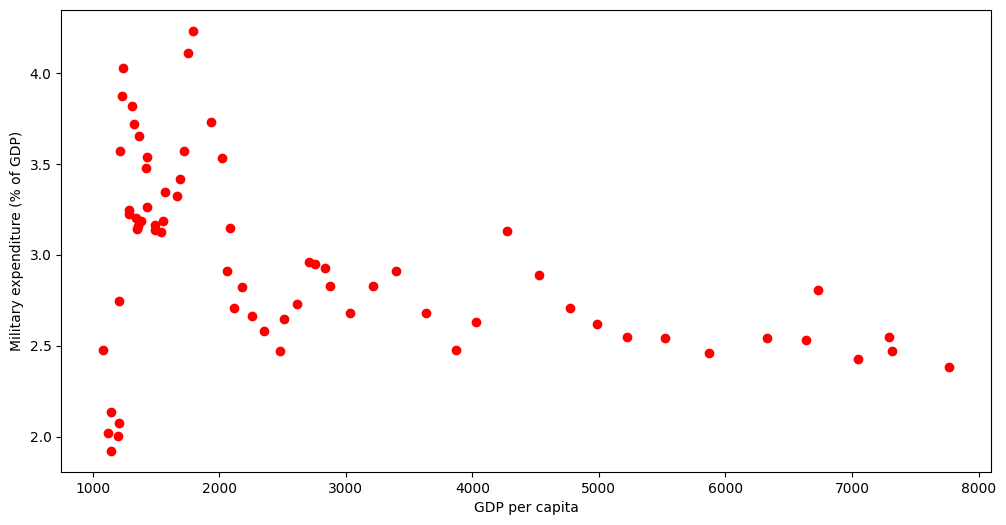

In [34]:
plt.figure(figsize=(12, 6))
plt.scatter(df_final['GDP per capita'],df_final['Military expenditure (% of GDP)'],color='red')
plt.xlabel("GDP per capita")
plt.ylabel("Military expenditure (% of GDP)")

- No outlier is present as per visual observation

#### Part 2 Answers for Report
1. No missing value was present
2. No outlier was detected
3. As X increases, Y increases suddenly then starts an exponential decay(decrement) gradually.
4. Yeah, a poisson distributional function can be a good fit since it is showing the changes like a poisson curve. So, a parametric regression can fit this data.

In [36]:
X=df_final['GDP per capita']
Y=df_final['Military expenditure (% of GDP)']

In [37]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error,mean_absolute_error

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)

#### KNN Smoother

In [38]:
from sklearn.neighbors import KNeighborsRegressor

folds=KFold(n_splits=5)

values_knn=[1,2,3,4,5,6,7,8,9,10]
knn_val_mse=[]
knn_val_mae=[]

for k in values_knn:
    mse_fold = []
    mae_fold = []
    for train_index, val_index in folds.split(X,Y):
        x_tr, x_val = X[train_index], X[val_index]
        y_tr, y_val = Y[train_index], Y[val_index]

        x_tr=x_tr.values.reshape(-1,1)
        x_val=x_val.values.reshape(-1,1)
        
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(x_tr, y_tr)
        y_hat=knn.predict(x_val)
        
        mse_fold.append(mean_squared_error(y_val, y_hat))
        mae_fold.append(mean_absolute_error(y_val, y_hat))
    
    knn_val_mse.append(np.mean(mse_fold))
    knn_val_mae.append(np.mean(mae_fold))

print(knn_val_mse)
print(knn_val_mae)

[np.float64(0.383425199598841), np.float64(0.2602249475149154), np.float64(0.23069040688149145), np.float64(0.2474797630341134), np.float64(0.2461564235247705), np.float64(0.2500564873435466), np.float64(0.24133560067045515), np.float64(0.24426932503452375), np.float64(0.24454524744521788), np.float64(0.25360392383131836)]
[np.float64(0.45146986131868133), np.float64(0.3730811081318681), np.float64(0.34994119586080585), np.float64(0.3542233226373628), np.float64(0.3604851687472527), np.float64(0.3607155380402931), np.float64(0.3535200011930926), np.float64(0.3541102109752748), np.float64(0.36224935373626377), np.float64(0.3803440467912088)]


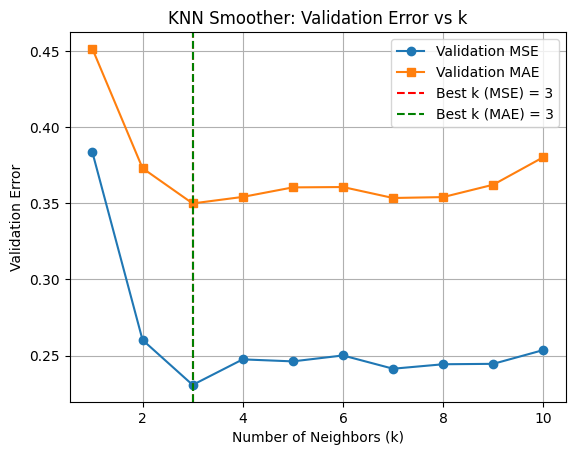

In [39]:
plt.plot(values_knn, knn_val_mse, marker='o', label='Validation MSE')
plt.plot(values_knn, knn_val_mae, marker='s', label='Validation MAE')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Error')
plt.title('KNN Smoother: Validation Error vs k')
plt.legend()
plt.grid(True)

# ---- Mark Optimal k ----
best_k_mse = values_knn[np.argmin(knn_val_mse)]
best_k_mae = values_knn[np.argmin(knn_val_mae)]
plt.axvline(best_k_mse, color='r', linestyle='--', label=f'Best k (MSE) = {best_k_mse}')
plt.axvline(best_k_mae, color='g', linestyle='--', label=f'Best k (MAE) = {best_k_mae}')

plt.legend()
plt.show()

###### Best KNN Model

In [21]:
x_train_knn=x_train.values.reshape(-1,1)
x_test_knn=x_test.values.reshape(-1,1)

model_knn=KNeighborsRegressor(n_neighbors=best_k_mse)

model_knn.fit(x_train_knn,y_train)
y_hat_knn=model_knn.predict(x_test_knn)

knn_test_mse=mean_squared_error(y_test,y_hat_knn)
print(f"Test MSE of KNN:{knn_test_mse}")

Test MSE of KNN:0.2767943302784125


#### WLLR Smoother

In [22]:
def gaussian(x):
    val=np.exp(-0.5*x*x)/np.sqrt(2*np.pi)
    return val
    
def WLLR(x0,h,x_train,y_train):
    n=len(x_train)
    b=np.array([1,0])                        ## Add 0s to use higher degree polynomials
    B=np.column_stack(([1]*n,(x_train-x0)))  ## (x0 - X_train)**2, Add higher degree terms for higher polynomials
    w=np.diag(gaussian((x_train-x0)/h))

    val=b @ np.linalg.pinv(B.T @ w @ B) @ B.T @ w @ y_train

    return val

In [23]:
folds=KFold(n_splits=5)

values_wllr=[50,100,150,200,250,300,350,400,450,500]
wllr_val_mse=[]
wllr_val_mae=[]

for h in values_wllr:
    mse_fold = []
    mae_fold = []
    for train_index, val_index in folds.split(X,Y):
        x_tr, x_val = X[train_index], X[val_index]
        y_tr, y_val = Y[train_index], Y[val_index]
        
        y_hat=[]
        for x in x_val:
            y_hat.append(WLLR(x,h,x_tr,y_tr))

        mse_fold.append(mean_squared_error(y_val, y_hat))
        mae_fold.append(mean_absolute_error(y_val, y_hat))
        
    wllr_val_mse.append(np.mean(mse_fold))
    wllr_val_mae.append(np.mean(mae_fold))

print(wllr_val_mse)
print(wllr_val_mae)

[np.float64(4.17351066240215), np.float64(1.7197228792388664), np.float64(1.5153797798944026), np.float64(1.8934272577597249), np.float64(4.387248741316663), np.float64(5.232862699926018), np.float64(5.131654812438144), np.float64(4.955877947504209), np.float64(4.70513457776622), np.float64(4.38966731913183)]
[np.float64(1.4786182163037278), np.float64(0.9338874087444798), np.float64(0.8673722775571999), np.float64(0.9128434568469117), np.float64(1.1861541983291208), np.float64(1.2642772159835072), np.float64(1.2516646538781462), np.float64(1.2249078738655306), np.float64(1.1857923096640686), np.float64(1.1378673134424588)]


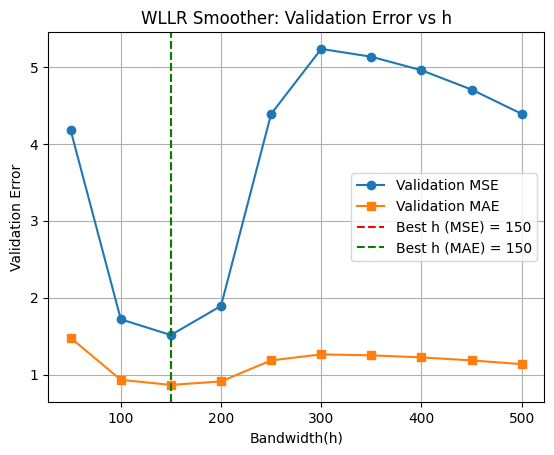

In [24]:
plt.plot(values_wllr, wllr_val_mse, marker='o', label='Validation MSE')
plt.plot(values_wllr, wllr_val_mae, marker='s', label='Validation MAE')
plt.xlabel('Bandwidth(h)')
plt.ylabel('Validation Error')
plt.title('WLLR Smoother: Validation Error vs h')
plt.legend()
plt.grid(True)

# ---- Mark Optimal h ----
best_h_mse = values_wllr[np.argmin(wllr_val_mse)]
best_h_mae = values_wllr[np.argmin(wllr_val_mae)]
plt.axvline(best_h_mse, color='r', linestyle='--', label=f'Best h (MSE) = {best_h_mse}')
plt.axvline(best_h_mae, color='g', linestyle='--', label=f'Best h (MAE) = {best_h_mae}')

plt.legend()
plt.show()

###### Best WLLR Model

In [25]:
y_hat_wllr=[]
for x in x_test:
    y_hat_wllr.append(WLLR(x,best_k_mse,x_train,y_train))

wllr_test_mse=mean_squared_error(y_test,y_hat_wllr)
print(f"Test MSE of WLLR:{wllr_test_mse}")

Test MSE of WLLR:6.200523558712652


#### LOWESS

In [26]:
from statsmodels.nonparametric.smoothers_lowess import lowess

folds = KFold(n_splits=5)

values_lowess = [0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24, 0.26, 0.28]
lowess_val_mse = []
lowess_val_mae = []

# Ensure numpy arrays
X = np.array(X).flatten()
Y = np.array(Y).flatten()

for f in values_lowess:
    mse_fold, mae_fold = [], []
    for train_index, val_index in folds.split(X, Y):
        x_tr, x_val = X[train_index], X[val_index]
        y_tr, y_val = Y[train_index], Y[val_index]

        smoothed = lowess(y_tr, x_tr, frac=f, return_sorted=True)
        xs, ys = smoothed[:,0], smoothed[:,1]

        # Interpolate prediction
        y_hat = np.interp(x_val, xs, ys)

        mse_fold.append(mean_squared_error(y_val, y_hat))
        mae_fold.append(mean_absolute_error(y_val, y_hat))
    
    lowess_val_mse.append(np.mean(mse_fold))
    lowess_val_mae.append(np.mean(mae_fold))

print("MSE:", lowess_val_mse)
print("MAE:", lowess_val_mae)


MSE: [np.float64(0.3787871836776839), np.float64(0.3650148615815973), np.float64(0.32831472963368963), np.float64(0.2989155880860843), np.float64(0.28994138365907146), np.float64(0.2503423920353125), np.float64(0.2532653435009519), np.float64(0.27098218501431875), np.float64(0.2749787856970786), np.float64(0.2868228405694326), np.float64(0.29592977821471733)]
MAE: [np.float64(0.4382558986790238), np.float64(0.4267846480871354), np.float64(0.4047612316674961), np.float64(0.3850450288670259), np.float64(0.37995677219050095), np.float64(0.36908742530703376), np.float64(0.37526554238873244), np.float64(0.3923734336911916), np.float64(0.3948731413842189), np.float64(0.4091927318560078), np.float64(0.42192484721081136)]


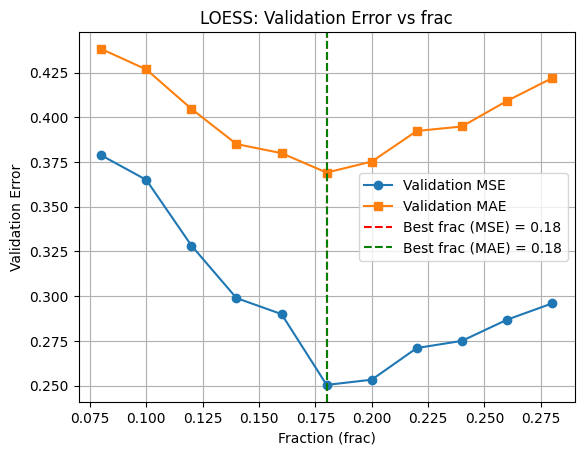

In [27]:
best_f_mse = values_lowess[np.argmin(lowess_val_mse)]
best_f_mae = values_lowess[np.argmin(lowess_val_mae)]

plt.plot(values_lowess, lowess_val_mse, 'o-', label='Validation MSE')
plt.plot(values_lowess, lowess_val_mae, 's-', label='Validation MAE')
plt.axvline(best_f_mse, color='r', linestyle='--', label=f'Best frac (MSE) = {best_f_mse}')
plt.axvline(best_f_mae, color='g', linestyle='--', label=f'Best frac (MAE) = {best_f_mae}')
plt.xlabel('Fraction (frac)')
plt.ylabel('Validation Error')
plt.title('LOESS: Validation Error vs frac')
plt.legend()
plt.grid(True)
plt.show()


###### Best LOWESS Model

In [28]:
best_lowess=lowess(y_tr, x_tr, frac=f, return_sorted=True)
xs, ys = best_lowess[:,0], best_lowess[:,1]

y_hat_lowess=np.interp(x_test, xs, ys)

lowess_test_MSE=mean_squared_error(y_test,y_hat_lowess)
print(f"Test MSE of LOWESS:{lowess_test_MSE}")

Test MSE of LOWESS:0.046069246515073776


#### Part 3 Answers for Report
1. For KNN, hyperparameter k(number of nearest neighbours) is tuned. For WLLR, hyperparameter h(bandwidth) is tuned. For LOWESS, hyperparameter f(fraction of local population) is tuned.
2. When the value of hyperparameter increases, the validation error decreases and reaches a minimum point then starts increasing.
3. I have used 5-folds in cross-validation because it balances bias-variance tradeoff, ensures enough data in each training fold, and reduces variance in validation scores without being computationally expensive.
4. **MSE(Mean Squared Error)**  
   - **Pro:** Penalizes larger errors more heavily, which helps detect when the model makes big mistakes.  
   - **Con:** Highly sensitive to outliers, meaning a few large errors can distort the overall evaluation.

   **MAE (Mean Absolute Error)**  
   - **Pro:** Easy to interpret since it represents the average error in the same units as the target variable.  
   - **Con:** Treats all errors equally, so it does not emphasize large errors as strongly as MSE.

6. LOWESS performed best on the test data with Test Error 0.046069 because the underlying relationship is smoothly varying, and LOWESS is designed to capture such smooth non-linear patterns effectively without overfitting.

In [29]:
result=pd.DataFrame({'Method':['KNN','WLLR','LOWESS'], 
                     'Best Hyperparameter':[best_k_mse,best_h_mse,best_f_mse], 
                     'Validation MSE':[np.min(knn_val_mse),np.min(wllr_val_mse),np.min(lowess_val_mse)], 
                     'Validation MAE':[np.min(knn_val_mae),np.min(wllr_val_mae),np.min(lowess_val_mae)],
                     'Test Error':[knn_test_mse,wllr_test_mse,lowess_test_MSE]})
result

,Method,Best Hyperparameter,Validation MSE,Validation MAE,Test Error
0,KNN,3.00,0.230690,0.349941,0.276794
1,WLLR,150.00,1.515380,0.867372,6.200524
2,LOWESS,0.18,0.250342,0.369087,0.046069


- LOWESS gives the best fit because of the least Test Error.

In [30]:
X_knn=X.reshape(-1,1)
y_final_knn=model_knn.predict(X_knn)

y_final_WLLR=[]
h=best_h_mse
for x in X:
    y_final_WLLR.append(WLLR(x,h,x_train,y_train))

y_final_lowess=np.interp(X, xs, ys)

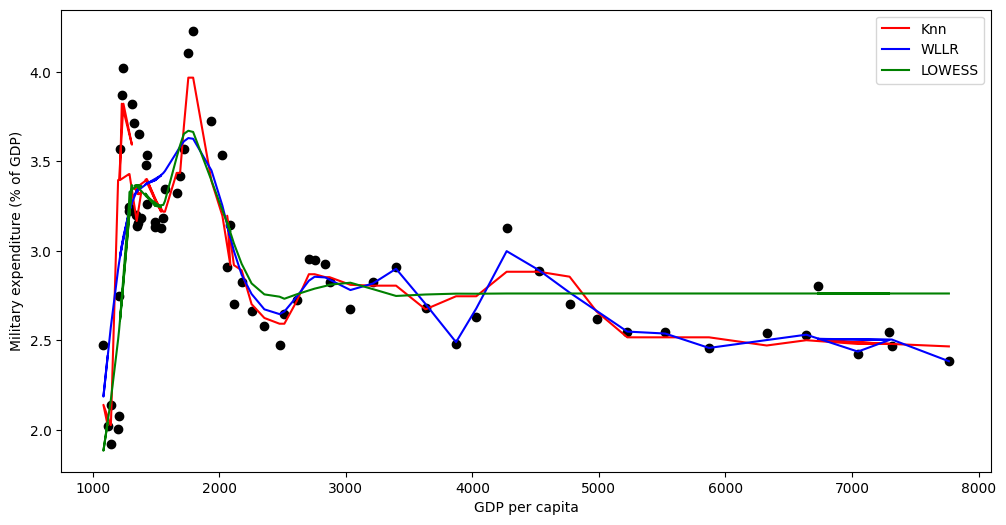

In [31]:
plt.figure(figsize=(12, 6))

plt.scatter(X,Y,color='black')
plt.plot(X,y_final_knn,label="Knn",color='red')
plt.plot(X,y_final_WLLR,label="WLLR",color='blue')
plt.plot(X,y_final_lowess,label="LOWESS",color='green')

plt.xlabel("GDP per capita")
plt.ylabel("Military expenditure (% of GDP)")
plt.legend()

#### Part 4 Answers for Report
1. LOWESS performed best on the test data with Test Error 0.046069 because the underlying relationship is smoothly varying, and LOWESS is designed to capture such smooth non-linear patterns effectively without overfitting.
2. Yes, the best-performing model (LOWESS) is also the smoothest visually, and this smoothness helped it capture the underlying trend without overfitting local noise.
3. Another smoother would outperform LOWESS when the underlying relationship is more locally irregular, more linear, or when computational efficiency or robustness to outliers is more important than achieving a globally smooth trend.
4. This project demonstrates that nonparametric regressors are highly sensitive to their smoothing hyperparameters, such as the number of neighbors in KNN or the smoothing fraction in LOWESS. These parameters directly control the bias–variance trade-off: too little smoothing leads to overfitting, while too much smoothing leads to oversimplification and underfitting. The differences in performance across models in this project showed that the choice of smoother alone is not enough—the model only performed well after carefully tuning its hyperparameters. Therefore, effective hyperparameter tuning is essential for nonparametric regression to accurately capture the underlying structure of the data.

#### Inference
- LOWESS performed best on the test data with Test Error 0.046069 because the underlying relationship is smoothly varying, and LOWESS is designed to capture such smooth non-linear patterns effectively without overfitting.
- WLLR significantly underperformed, likely because its large bandwidth oversmoothed the data, causing it to miss the curvature of the relationship.
- KNN performed moderately well but remained sensitive to local variability and produced a less smooth fit compared to LOWESS.